# Statistical Learning

# Introduction to Statistical Learning

What is Statistical Learning?

A set of tools and math techniques to **understand data** and **make predictions**.

## 1. Inputs and Output

We want to predict an output \(Y\) using input features \(X\).

Example: predicting **Sales** using advertising:

$$
X_1=\text{TV},\qquad
X_2=\text{Radio},\qquad
X_3=\text{Newspaper}
$$

The entire input vector is:

$$
\boxed{
X=
\begin{bmatrix}
X_1\\
X_2\\
X_3
\end{bmatrix}}
$$

* \(X\) = all input variables together
* \(X_1,X_2,X_3\) = individual input variables
* \(Y\) = output/random variable

---

## 2. Capital vs. Small Letters

**Capital letters = random variables / general variables**

$$
X=(X_1,X_2,X_3)
$$

**Small letters = specific observed values**

For one campaign:

$$
x=
\begin{bmatrix}
x_1\\x_2\\x_3
\end{bmatrix}
=
\begin{bmatrix}
100\\50\\20
\end{bmatrix}
$$

So:

$$
X_1\rightarrow x_1=100
$$

$$
X_2\rightarrow x_2=50
$$

$$
X_3\rightarrow x_3=20
$$

And:

$$
X\rightarrow x=
\begin{bmatrix}
100\\50\\20
\end{bmatrix}
$$

**Think:**

> \(X\) = the variable in general
> \(x\) = one particular value/observation

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible random data
np.random.seed(42)

# Number of marketing campaigns
n = 200

# Input features
tv = np.random.uniform(0, 300, n)
radio = np.random.uniform(0, 50, n)
newspaper = np.random.uniform(0, 100, n)

# Random noise (epsilon)
epsilon = np.random.normal(0, 2, n)

# Output variable
# This is the unknown relationship f(X) + epsilon
sales = (
        3
        + 0.05 * tv
        + 0.15 * radio
        + 0.01 * newspaper
        + epsilon
)

# Create dataset
df = pd.DataFrame({
    "TV": tv,
    "Radio": radio,
    "Newspaper": newspaper,
    "Sales": sales
})


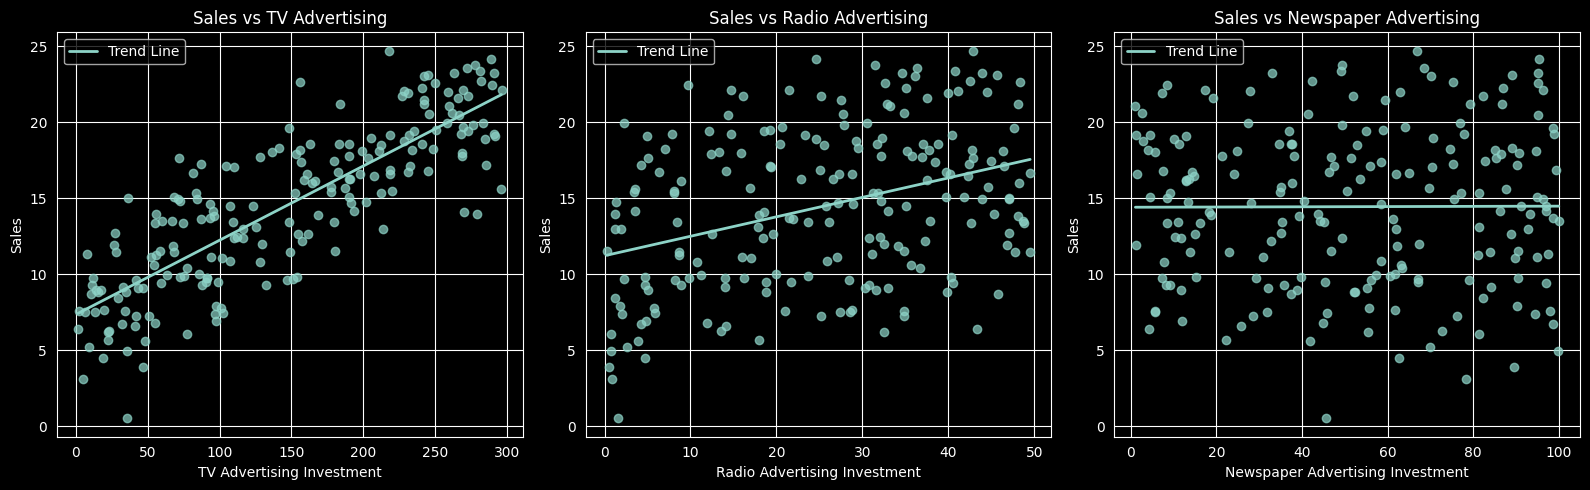

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ["TV", "Radio", "Newspaper"]

for ax, feature in zip(axes, features):
    # Scatter plot
    ax.scatter(
        df[feature],
        df["Sales"],
        alpha=0.7
    )

    # Calculate linear trend line
    slope, intercept = np.polyfit(
        df[feature],
        df["Sales"],
        1
    )

    # Generate x values for the line
    x_values = np.linspace(
        df[feature].min(),
        df[feature].max(),
        100
    )

    # Calculate corresponding y values
    y_values = slope * x_values + intercept

    # Plot trend line
    ax.plot(
        x_values,
        y_values,
        linewidth=2,
        label="Trend Line"
    )

    # Labels
    ax.set_title(f"Sales vs {feature} Advertising")
    ax.set_xlabel(f"{feature} Advertising Investment")
    ax.set_ylabel("Sales")
    ax.legend()

plt.tight_layout()
plt.show()

### 3. 200 Observations

If we have 200 campaigns, we still only have 3 input variables:

$$
X_1,X_2,X_3
$$

But we observe them 200 times:

$$
x^{(1)},x^{(2)},...,x^{(200)}
$$

Each observation is a 3-dimensional vector:

$$
x^{(i)}=
\begin{bmatrix}
x_1^{(i)}\\
x_2^{(i)}\\
x_3^{(i)}
\end{bmatrix}
$$

So:

$$
\boxed{3\text{ features}\times200\text{ observations}}
$$

---

# 4. Additive Model

The basic model is:

$$
\boxed{Y=f(X)+\epsilon}
$$

Meaning:

$$
\boxed{
\text{Actual output}
=
\text{underlying relationship}
+
\text{random noise}
}
$$

### \(f(X)\)

\(f\) = unknown **regression function**.

It represents the systematic relationship between inputs and output.

$$
f(X)=\text{what the inputs explain}
$$

### \(\epsilon\)

$$
\epsilon=\text{random error/noise}
$$

It represents things affecting \(Y\) that aren't captured by \(X\).

Examples:

* weather
* competitors
* customer behavior
* random events
* measurement error

---

## 5. Expected Error

We assume:

$$
\boxed{E[\epsilon]=0}
$$

This does **NOT** mean every error is zero.

It means:

> Errors are centered around zero and, on average, don't systematically push predictions up or down.

Example:

$$
+10,-10,+5,-5
$$

Average:

$$
E[\epsilon]\approx0
$$

So the model isn't systematically overpredicting or underpredicting.

---

## 6. Variance of the Error

We also assume:

$$
\boxed{Var(\epsilon)=\sigma^2}
$$

Variance tells us how much the random errors **spread around zero**.

Because:

$$
E[\epsilon]=0
$$

we have:

$$
\boxed{Var(\epsilon)=E[\epsilon^2]=\sigma^2}
$$

So:

* \(E[\epsilon]\) → **direction/bias of error**
* \(Var(\epsilon)\) → **spread/size of random error**

---

## 7. MSE

For observed data, we calculate residuals:

$$
e_i=y_i-\hat f(x_i)
$$

MSE:

$$
\boxed{
MSE=\frac{1}{n}\sum_{i=1}^{n}e_i^2
}
$$

MSE tells us:

> **How large our prediction errors are, regardless of whether they are positive or negative.**

Because squaring makes:

$$
(+10)^2=(-10)^2=100
$$

---

## 8. Two Different Questions

When evaluating a model:

### Question 1:

**"Am I systematically too high or too low?"**

Look at:

$$
\boxed{\text{Average error}\approx0}
$$

### Question 2:

**"How far off are my predictions?"**

Look at:

$$
\boxed{MSE}
$$

Ideally:

$$
\boxed{
\text{Average error}\approx0
\quad\text{AND}\quad
MSE\text{ is small}
}
$$

---

## 9. Big Picture

$$
\boxed{
Y=f(X)+\epsilon
}
$$

Think:

$$
\underbrace{Y}_{\text{what actually happens}}
=
\underbrace{f(X)}_{\text{what inputs explain}}
+
\underbrace{\epsilon}_{\text{random/unexplained part}}
$$

The goal of statistical learning is to use historical data to estimate the unknown function:

$$
\boxed{f(X)\rightarrow\hat f(X)}
$$

so that we can make good predictions for new \(x\)'s.


>  Epsilon tells us how much of the output is **unexplained** by the inputs. The smaller the variance of epsilon, the better our inputs explain the output. Variance tells us how much the output varies around the predicted value. If variance is small, our predictions are more reliable.

# Regression Function

Goal: We want to predict \(Y\) using \(X\).
$$
y = f(X) + \epsilon
$$

What is regression function?

$$
\boxed{ \text{THEORY: } f(x) = E[Y \mid X = x] }
$$

$$
\boxed{ \text{PRACTICE: } \hat{f}(x) = \frac{1}{|D(x)|} \sum_{i \in D(x)} Y_i }
$$

In practice, we estimate \(f(x)\) using the average of observed \(Y\) values for similar\(nearby\) \(X\) values.

-----

The regression function is defined as the conditional expectation:

### Intuition

$E[Y \mid X=x]$ means:

> The average value of $Y$ among observations where $X$ is equal to $x$.

For example, if $X$ represents years of experience and $Y$ represents salary,
then:

$$
f(5) = E[Y \mid X=5]
$$

means:

> What is the average salary for people with 5 years of experience?

Therefore:

$$
\boxed{\text{Regression function} = \text{conditional average of }Y\text{ given }X}
$$

## Why Conditional Expectation?

### Why does the conditional expectation matter?

If we knew the conditional probability density function of $Y$ given $X=x$,
we could calculate the regression function using:

$$
f(x)
=
E[Y\mid X=x]
=
\int y f_{Y\mid X}(y\mid x)\,dy
$$

However, in practice we usually **do not know** the conditional probability
distribution $f_{Y\mid X}$.

Instead, we have a dataset and must estimate $f(x)$ from the data.

## Regression as Minimizing MSE

## 2. Regression as an Optimization Problem

The regression function is also the function that minimizes the expected
squared prediction error:

$$
\boxed{
f
=
\arg\min_g E[(Y-g(X))^2]
}
$$

Here, $g(X)$ represents a possible prediction function.

The different parts have simple meanings:

$$
Y-g(X)
=
\text{prediction error}
$$

$$
(Y-g(X))^2
=
\text{squared error}
$$

$$
E[(Y-g(X))^2]
=
\text{Mean Squared Error (MSE)}
$$

Therefore:

$$
\boxed{
\text{Best prediction under squared error}
=
E[Y\mid X]
}
$$

This is an important theoretical result:

$$
\boxed{
f(x)=E[Y\mid X=x]
}
$$

is the function that gives the smallest possible expected squared error.





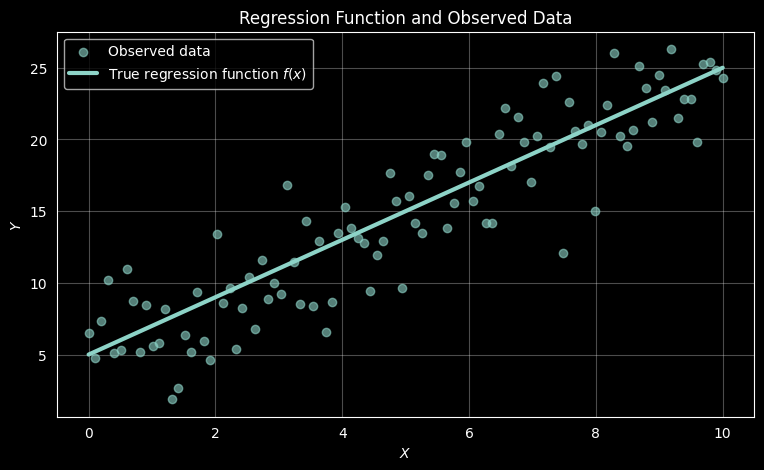

In [6]:
"""
Visualize the Regression Idea

For the graph, I'd use simulated data so you can actually see the noise around the true regression function.

The important thing to notice:

The points are scattered because of (epsilon), but the line represents the underlying relationship (f(X)).

"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate X values
X = np.linspace(0, 10, 100)

# True regression function
f_X = 2 * X + 5

# Add random noise
epsilon = np.random.normal(0, 3, size=len(X))

# Observed Y
Y = f_X + epsilon

plt.figure(figsize=(9, 5))

plt.scatter(X, Y, alpha=0.6, label="Observed data")
plt.plot(X, f_X, linewidth=3, label=r"True regression function $f(x)$")

plt.xlabel(r"$X$")
plt.ylabel(r"$Y$")
plt.title("Regression Function and Observed Data")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The Statistical Learning Problem

In practice, we do not know the true regression function $f$.

Instead, we observe a dataset:

$$
D =
\{(X_1,Y_1),(X_2,Y_2),\ldots,(X_n,Y_n)\}
$$

and want to construct an estimate:

$$
\boxed{\hat f}
$$

such that:

$$
\hat f(x) \approx f(x)
$$

The data is assumed to come from:

$$
\boxed{Y_i=f(X_i)+\epsilon_i}
$$

with:

$$
E[\epsilon_i]=0
$$

and:

$$
Var(\epsilon_i)=\sigma^2
$$

Our goal is therefore:

$$
\boxed{\text{Use the data to estimate the unknown function }f}
$$


## Why Can't We Just Average Exact \(X=x\)?

## A Naive Approach

Since:

$$
f(x)=E[Y\mid X=x]
$$

we might try to estimate $f(x)$ by finding all observations where:

$$
X_i=x
$$

and averaging their corresponding $Y_i$ values.

Define:

$$
D_x=\{i:X_i=x\}
$$

Then:

$$
\hat f(x)
=
\frac{1}{|D_x|}
\sum_{i\in D_x}Y_i
$$

### Problem

When $X$ is continuous, it is extremely unlikely that we will observe:

$$
X_i=x
$$

for an exact value of $x$.

For example, if we want $x=2$, our data might contain:

$$
1.97,\quad 2.03,\quad 2.08,\quad 1.91
$$

but no observation where:

$$
X_i=2.0000
$$

So the set $D_x$ may contain no observations.

## The Solution: Nearby Points

## Use Nearby Observations

Instead of requiring:

$$
X_i=x
$$

we allow observations that are **close to $x$**.

Define:

$$
\boxed{
D_r(x)
=
\{i:\|X_i-x\|\leq r\}
}
$$

### What does this notation mean?

- $D_r(x)$ = set of observations we will use
- $i$ = observation index
- $X_i$ = input of observation $i$
- $x$ = input where we want to make a prediction
- $\|X_i-x\|$ = distance between $X_i$ and $x$
- $r$ = how far away we are willing to look

In one dimension:

$$
\|X_i-x\|=|X_i-x|
$$

So:

$$
|X_i-x|\leq r
$$

simply means:

> $X_i$ is within $r$ units of $x$.


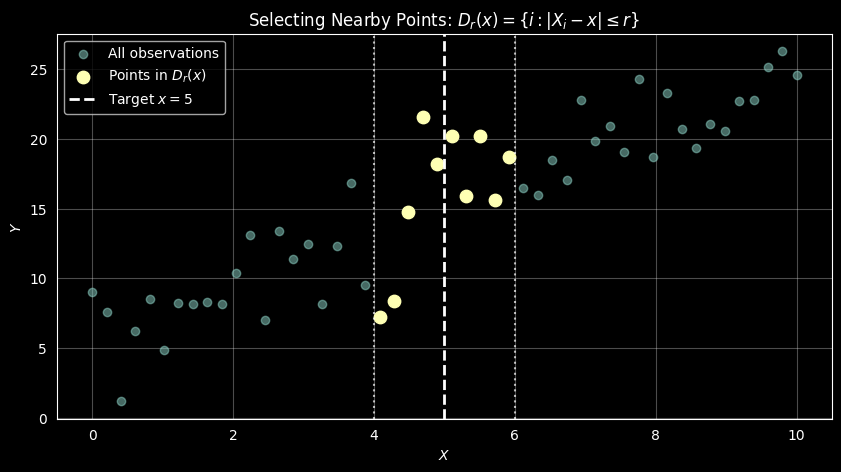

In [4]:
# Generate example data
np.random.seed(10)

X = np.linspace(0, 10, 50)
Y = 2 * X + 5 + np.random.normal(0, 3, 50)

# Prediction location and radius
x_target = 5
r = 1

# Points inside the window
inside = np.abs(X - x_target) <= r

plt.figure(figsize=(10, 5))

# All observations
plt.scatter(X, Y, alpha=0.5, label="All observations")

# Nearby observations
plt.scatter(
    X[inside],
    Y[inside],
    s=80,
    label=r"Points in $D_r(x)$"
)

# Target x
plt.axvline(
    x_target,
    linestyle="--",
    linewidth=2,
    label=r"Target $x=5$"
)

# Window boundaries
plt.axvline(x_target - r, linestyle=":", alpha=0.7)
plt.axvline(x_target + r, linestyle=":", alpha=0.7)

plt.xlabel(r"$X$")
plt.ylabel(r"$Y$")
plt.title(r"Selecting Nearby Points: $D_r(x)=\{i:|X_i-x|\leq r\}$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Summary

### Theoretical regression function

$$
\boxed{f(x)=E[Y\mid X=x]}
$$

The regression function gives the **average value of $Y$ for a given $X$**.

---

### Equivalent optimization view

$$
\boxed{
f=\arg\min_g E[(Y-g(X))^2]
}
$$

The regression function is the function that minimizes **expected squared prediction error**.

---

### In practice

We have data:

$$
D=\{(X_i,Y_i)\}_{i=1}^{n}
$$

but we don't know $f$.

Instead, we estimate it.

---

### Exact matching

$$
D_x=\{i:X_i=x\}
$$

Usually doesn't work for continuous $X$.

---

### Nearby observations

$$
\boxed{
D_r(x)=\{i:\|X_i-x\|\leq r\}
}
$$

Find observations close to $x$.

---

### Average their outputs

$$
\boxed{
\hat f(x)
=
\frac{1}{|D_r(x)|}
\sum_{i\in D_r(x)}Y_i
}
$$

### Big picture

$$
\boxed{
\text{Find nearby }X_i
\rightarrow
\text{collect their }Y_i
\rightarrow
\text{average}
\rightarrow
\hat f(x)
}
$$

# Curse of Dimensionality

Local averaging works nicely in 1 dimension, but as the number of input features/dimensions \(p\) increases, the amount of data near any particular point shrinks exponentially. This is the curse of dimensionality.

* In 1D we can find many points near \(x\) within a small radius \(r\).
* In 2D, we need to consider a square or circle around \(x\)
* In 3D, a cube or sphere.
* As the number of dimensions increases, the volume of the space grows exponentially, and the density of data points decreases. This means that for high-dimensional data, we may have very few or no points near \(x\), making local averaging unreliable.

In real life machine learning problems $X =! X_1$. It is

$$
X =
\begin{bmatrix} X_1 \\ X_2 \\ X_3 \\ .\\.\\. \\ X_p
\end{bmatrix}
$$

For example, age, income, education level, and many other features could all be part of \(X\). As \(p\) increases, the curse of dimensionality becomes more pronounced.

$$
X=
\begin{bmatrix}
Age\\
Income\\
Education\\
.\\.\\.\\
X_p
\end{bmatrix}
$$


The whole idea:
1. Local averaging predicts \(f(x)\) by averaging \(Y_i\)'s near \(x\).
2. In \(p\) dimensions, a neighborhood of radius \(r\) occupies a fraction approximately \(r^p\) of the space.
3. With \(N\) observations, the expected number of observations in that neighborhood is
$$ \boxed{Nr^p} $$
4. For \(r<1\), \(r^p\) decreases exponentially as \(p\) increases.
5. Therefore, high-dimensional data has almost no observations near any particular \(x\), making local averaging impractical.

## 1. Local Averaging

Suppose we want to estimate the regression function

$$
f(x)=E[Y\mid X=x].
$$

A simple approach is **local averaging**:

> To predict \(Y\) at \(x\), look at observations whose \(X_i\)'s are close to \(x\), and average their \(Y_i\)'s.

Define a neighborhood around \(x\):

$$
D_r(x)=\{z:\|z-x\|\le r\}
$$

where \(r\) is the radius of the neighborhood.

So:

$$
\boxed{
\hat f(x)
=
\frac{1}{\#D_r(x)}
\sum_{i:X_i\in D_r(x)}Y_i
}
$$

The method works well **only if there are enough observations near \(x\)**.

---

# 2. The Key Question

Suppose we have \(N\) observations uniformly distributed in a \(p\)-dimensional space.

### Question:

**How many observations do we expect to find within distance \(r\) of \(x\)?**

The answer is:

$$
\boxed{Nr^p}
$$

Let's see exactly why.

---

# 3. Where Does \(Nr^p\) Come From?

The intuition is:

$$
\boxed{
\text{Expected points}
=
\text{point density}
\times
\text{volume of neighborhood}
}
$$

We can derive each part separately.

---

## Step 1: Point Density

Suppose \(N\) points are uniformly distributed inside a large \(p\)-dimensional sphere of radius \(1\).

The volume of a \(p\)-dimensional sphere is

$$
V_p(R)=K_pR^p
$$

where \(K_p\) is a constant that depends only on \(p\).

For radius \(1\):

$$
V_p(1)=K_p
$$

Therefore the density of points is

$$
\boxed{
\text{density}
=
\frac{N}{K_p}
}
$$

---

## Step 2: Volume of the Local Neighborhood

Now put a small \(p\)-dimensional sphere of radius \(r\) around \(x\).

Its volume is

$$
V_p(r)=K_pr^p.
$$

So the fraction of the entire space occupied by the small neighborhood is

$$
\frac{K_pr^p}{K_p}
=
r^p.
$$

Therefore:

$$
\boxed{
\text{fraction of points nearby}=r^p
}
$$

---

## Step 3: Multiply by \(N\)

If \(r^p\) is the fraction of the space occupied by our neighborhood, and we have \(N\) total observations:

$$
\text{Expected points}
=
N(r^p)
$$

Therefore:

$$
\boxed{
E[\#\text{ points near }x]=Nr^p
}
$$

###  This is the important formula.

---

# 4. Why Does the Exponent Become \(p\)?

This is the most important intuition.

The neighborhood gets a different type of "volume" depending on the number of dimensions.

### 1 dimension

A neighborhood is approximately a line segment:

$$
\text{size}\propto r
$$

So:

$$
\boxed{Nr}
$$

---

### 2 dimensions

A neighborhood is a circle:

$$
\text{area}\propto r^2
$$

So:

$$
\boxed{Nr^2}
$$

---

### 3 dimensions

A neighborhood is a sphere:

$$
\text{volume}\propto r^3
$$

So:

$$
\boxed{Nr^3}
$$

---

### \(p\) dimensions

The volume scales as:

$$
\boxed{r^p}
$$

Therefore:

$$
\boxed{Nr^p}
$$

---

# 5. Visual Intuition

Think of \(r=0.1\).

Every additional dimension multiplies the fraction of nearby space by another \(0.1\):

$$
0.1
$$

$$
0.1\times0.1=0.01
$$

$$
0.1\times0.1\times0.1=0.001
$$

So:

$$
\boxed{
0.1^p
}
$$

shrinks extremely quickly.

### With \(N=1000\):

| Dimensions \(p\) | Expected nearby points |
| ---------------: | ---------------------: |
|                1 |      \(1000(0.1)=100\) |
|                2 |     \(1000(0.1)^2=10\) |
|                3 |      \(1000(0.1)^3=1\) |
|                4 |    \(1000(0.1)^4=0.1\) |
|                5 |   \(1000(0.1)^5=0.01\) |

So increasing the dimension causes the number of nearby observations to collapse.

---

# 6. The Curse of Dimensionality

For \(0<r<1\),

$$
r^p\rightarrow0
\qquad\text{as }p\rightarrow\infty.
$$

Therefore,

$$
Nr^p\rightarrow0.
$$

In words:

> **As the number of dimensions increases, observations become increasingly spread out, so there are fewer and fewer observations close to any particular \(x\).**

This is called the **curse of dimensionality**.

---

# 7. Why Does This Break Local Averaging?

Local averaging needs observations near \(x\):

$$
\hat f(x)
=
\text{average of nearby }Y_i.
$$

But in high dimensions:

$$
Nr^p\approx0.
$$

So there may be almost **nothing to average**.

### Low dimension

```text
        • •
      •  🔴  •
        • •

Many nearby observations
→ reliable local average
```

### High dimension

```text
•


                    🔴


        •


                              •


Very few nearby observations
→ unreliable local average
```

Therefore:

$$
\boxed{
\text{High }p
\Rightarrow
\text{few local observations}
\Rightarrow
\text{local averaging fails}
}
$$

---

# 8. Why Can't We Just Make \(r\) Bigger?

We could increase \(r\).

That gives us more observations because

$$
Nr^p
$$

gets larger.

But now our neighborhood includes points that are farther away from \(x\).

So we have a tradeoff:

| Small \(r\)      | Large \(r\)       |
| ---------------- | ----------------- |
| Few observations | Many observations |
| Very local       | Less local        |
| High variance    | Lower variance    |
| Lower bias       | Higher bias       |

This is connected to the **bias-variance tradeoff**.

---

# 9. The Main Takeaway

The entire argument can be summarized as:

$$
\boxed{
\text{Local volume}
\propto r^p
}
$$

therefore

$$
\boxed{
\text{Expected local observations}
=Nr^p
}
$$

and because \(r<1\),

$$
\boxed{
r^p\text{ decreases exponentially as }p\text{ increases}.
}
$$

Therefore:

$$
\boxed{
\text{High dimensionality}
\Rightarrow
\text{data becomes sparse}
\Rightarrow
\text{local averaging becomes impractical}.
}
$$

###  Remember

$$
\boxed{Nr^p}
$$

**\(N\)** = total data points
**\(r\)** = radius of local neighborhood
**\(p\)** = number of dimensions/features


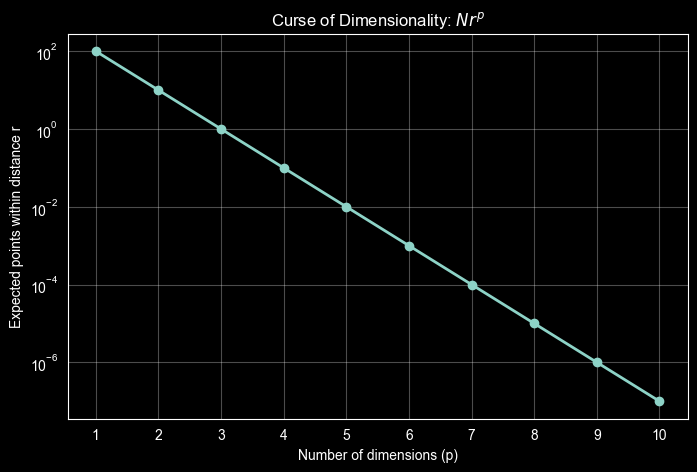

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1000
r = 0.1

# Dimensions 1 through 10
p = np.arange(1, 11)

# Expected number of nearby points
expected_points = N * r**p

plt.figure(figsize=(8, 5))

plt.plot(
    p,
    expected_points,
    marker="o",
    linewidth=2
)

# Log scale makes the exponential decrease easier to see
plt.yscale("log")

plt.xlabel("Number of dimensions (p)")
plt.ylabel("Expected points within distance r")
plt.title(r"Curse of Dimensionality: $Nr^p$")

plt.xticks(p)
plt.grid(True, which="both", alpha=0.3)

plt.show()

### What the graph means

We have:

$$
N=1000,\qquad r=0.1
$$

The expected number of observations inside a local neighborhood is:

$$
\boxed{Nr^p}
$$

Therefore:

$$
\begin{aligned}
p=1 &: \quad 1000(0.1)=100\\
p=2 &: \quad 1000(0.1)^2=10\\
p=3 &: \quad 1000(0.1)^3=1\\
p=4 &: \quad 1000(0.1)^4=0.1\\
p=5 &: \quad 1000(0.1)^5=0.01
\end{aligned}
$$

Each additional dimension multiplies the number of nearby observations by another factor of \(r=0.1\).

So:

$$
100
\rightarrow
10
\rightarrow
1
\rightarrow
0.1
\rightarrow
0.01
\rightarrow\cdots
$$

This is why local averaging becomes difficult in high dimensions.